# ACE and STEREO-A Correlation Plots

Build pred-only Miracle 2 forecast-correlation plots from the yearly per-CR stats. Dates are plotted on the lower x axis. ACE keeps an empty upper axis, and STEREO-A gets upper CH-observation-age and azimuth axes.


In [82]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd

pd.options.display.max_rows = 40


## Inputs and style

The visual styling follows the SW forecast panels: compact titles, light grids, small legends, and the forecast red color family.


In [83]:
ROOT = Path.cwd()
SW_ROOT = ROOT / "Outputs" / "SW" / "from Miracle 2" / "SW"
OUT_DIR = SW_ROOT / "Plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PER_CR_STATS = SW_ROOT / "SW Polar Animation 20180101_0000-20200101_0000 Per-CR Stats.csv"
STEREO_COORDS = ROOT / "Data" / "STEREO-A PLASTIC.parquet"

SAT_REGIMES = {
    "ACE @ Earth": ["no_icme", "no_icme_no_slow_sw"],
    "STEREO-A": ["all_sw", "no_slow_sw"],
}
REGIME_TITLES = {
    "all_sw": "All solar wind",
    "no_slow_sw": "No predicted slow wind",
    "no_icme": "No ICME",
    "no_icme_no_slow_sw": "No ICME, no predicted slow wind",
}

R_COLOR = "tab:blue"
RMSE_COLOR = "tab:red"
GRID_ALPHA = 0.25
FIG_DPI = 220
FIG_SIZE = (16.0, 4.8)


## Coordinate helpers

STEREO-A longitudes are averaged over each CR window with a circular mean. CH observation age uses the remaining Carrington-rotation travel from the observing meridian to STEREO-A, so negative STEREO longitudes map to late-rotation ages.


In [84]:
coords = pd.read_parquet(STEREO_COORDS, columns=["heliographicLongitude"])
coords = coords[~coords.index.duplicated(keep="first")].sort_index()
stereo_lon = coords["heliographicLongitude"].dropna()


def circular_mean_deg(values):
    radians = np.deg2rad(values.to_numpy(dtype=float))
    return float(np.rad2deg(np.arctan2(np.sin(radians).mean(), np.cos(radians).mean())))


def stereo_window_lon(start, end):
    lon_window = stereo_lon.loc[(stereo_lon.index >= start) & (stereo_lon.index < end)]
    return circular_mean_deg(lon_window)


def fisher_weighted_mean_r(group):
    valid = group[np.isfinite(group["r"]) & (group["n_samples"] > 3)].copy()
    z = np.arctanh(valid["r"].clip(-0.999999, 0.999999))
    weights = valid["n_samples"] - 3
    return float(np.tanh(np.average(z, weights=weights)))


def cr_range_label(cr_start, cr_end):
    return str(int(cr_start)) if int(cr_start) == int(cr_end) else f"{int(cr_start)}-{int(cr_end)}"


## Build per-CR and rolling tables

The rolling table reuses the per-CR rows but replaces `r` and `rmse` with centered, Fisher-weighted (r) and n_samples-weighted (rmse) rolling means. ACE rolls along CR number, STEREO-A along longitude (which grows monotonically with time on this trajectory).


In [85]:
ROLLING_WINDOW = 5

stats = pd.read_csv(PER_CR_STATS)
stats = stats[
    (stats["table"] == "forecast_skill")
    & (stats["forecast"] == "pred")
    & (stats["sat"].isin(SAT_REGIMES))
].copy()
stats = stats[stats.apply(lambda row: row["regime"] in SAT_REGIMES[row["sat"]], axis=1)].copy()
stats["r"] = pd.to_numeric(stats["r"], errors="coerce")
stats["rmse"] = pd.to_numeric(stats["rmse"], errors="coerce")
stats["n_samples"] = pd.to_numeric(stats["n_samples"], errors="coerce")
stats["cr_start_utc"] = pd.to_datetime(stats["cr_start"], utc=True)
stats["cr_end_utc"] = pd.to_datetime(stats["cr_end"], utc=True)
stats["cr_mid_utc"] = stats["cr_start_utc"] + (stats["cr_end_utc"] - stats["cr_start_utc"]) / 2
stats = stats[np.isfinite(stats["r"])].copy()

rows = []
for _, row in stats.iterrows():
    cr = int(row["cr"])
    out_row = {
        "sat": row["sat"],
        "regime": row["regime"],
        "forecast": row["forecast"],
        "cr_start_number": cr,
        "cr_end_number": cr,
        "cr_range": cr_range_label(cr, cr),
        "cr_center": float(cr),
        "cr_count": 1,
        "cr_start": row["cr_start"],
        "cr_end": row["cr_end"],
        "cr_mid": row["cr_mid_utc"].tz_convert(None),
        "n_samples": int(row["n_samples"]),
        "r": float(row["r"]),
        "rmse": float(row["rmse"]) if np.isfinite(row["rmse"]) else np.nan,
    }
    if row["sat"] == "STEREO-A":
        out_row["stereo_lon_circular_mean_deg"] = stereo_window_lon(
            row["cr_start_utc"],
            row["cr_end_utc"],
        )
    rows.append(out_row)

per_cr_df = pd.DataFrame(rows).sort_values(
    ["sat", "regime", "cr_start_number"]
).reset_index(drop=True)


def weighted_mean_rmse(group):
    valid = group[np.isfinite(group["rmse"]) & (group["n_samples"] > 0)]
    if valid.empty:
        return float("nan")
    return float(np.average(valid["rmse"], weights=valid["n_samples"]))


def rolling_smooth(df, x_column, window=ROLLING_WINDOW):
    half = window // 2
    out = []
    for (sat, regime), group in df.groupby(["sat", "regime"], sort=False):
        group = group.sort_values(x_column).reset_index(drop=True).copy()
        n = len(group)
        r_smooth = np.full(n, np.nan)
        rmse_smooth = np.full(n, np.nan)
        for i in range(n):
            lo = max(0, i - half)
            hi = min(n, i + half + 1)
            window_rows = group.iloc[lo:hi]
            r_smooth[i] = fisher_weighted_mean_r(window_rows)
            rmse_smooth[i] = weighted_mean_rmse(window_rows)
        group["r"] = r_smooth
        group["rmse"] = rmse_smooth
        out.append(group)
    return pd.concat(out, ignore_index=True)


ace_rolling = rolling_smooth(
    per_cr_df[per_cr_df["sat"] == "ACE @ Earth"],
    "cr_center",
)
stereo_rolling = rolling_smooth(
    per_cr_df[per_cr_df["sat"] == "STEREO-A"],
    "stereo_lon_circular_mean_deg",
)
rolling_df = pd.concat([ace_rolling, stereo_rolling], ignore_index=True)

per_cr_df.to_csv(OUT_DIR / "ACE Stereo Pred Corr Per-CR.csv", index=False)
rolling_df.to_csv(OUT_DIR / f"ACE Stereo Pred Corr Rolling-{ROLLING_WINDOW}.csv", index=False)

per_cr_df.groupby(["sat", "regime"]).size().rename("per_cr").to_frame()


per_cr
sat         regime                    
ACE @ Earth no_icme                 27
            no_icme_no_slow_sw      27
STEREO-A    all_sw                  27
            no_slow_sw              27

## CH age conversion for STEREO-A

Only STEREO-A gets the secondary age and azimuth axes. ACE keeps an empty upper axis.


In [86]:
per_cr_df["cr_start_dt"] = pd.to_datetime(per_cr_df["cr_start"])
per_cr_df["cr_end_dt"] = pd.to_datetime(per_cr_df["cr_end"])
cr_duration_days = (per_cr_df["cr_end_dt"] - per_cr_df["cr_start_dt"]).dt.total_seconds() / 86400
CR_PERIOD_DAYS = float(cr_duration_days[cr_duration_days > 26].median())


def lon_to_age(lon_deg):
    lon = np.asarray(lon_deg, dtype=float)
    return CR_PERIOD_DAYS * (1.0 + lon / 360.0)


def age_to_lon(age_days):
    age = np.asarray(age_days, dtype=float)
    return 360.0 * (age / CR_PERIOD_DAYS - 1.0)


pd.DataFrame(
    {
        "longitude_deg": [-120.0, -100.0, -80.0],
        "ch_observation_age_days": lon_to_age([-120.0, -100.0, -80.0]),
    }
)


,longitude_deg,ch_observation_age_days
0,-120.0,18.183057
1,-100.0,19.698312
2,-80.0,21.213566


## Plot helpers


In [87]:
def label_points(axis, frame, x_column, y_column, color):
    for _, point in frame.iterrows():
        if not np.isfinite(point[y_column]):
            continue
        axis.annotate(
            point["cr_range"],
            (point["_plot_x"], point[y_column]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=10,
            color=color,
            alpha=0.85,
        )


def padded_limits(values, pad_frac=0.08, floor_zero=False):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return (0.0, 1.0)
    lo = float(values.min())
    hi = float(values.max())
    span = max(hi - lo, 1e-6)
    pad = span * pad_frac
    lo_p = 0.0 if floor_zero else lo - pad
    hi_p = hi + pad
    return (lo_p, hi_p)


def date_axis_values(values):
    date_values = pd.to_datetime(values)
    return mdates.date2num([value.to_pydatetime() for value in date_values])


def stereo_date_axis_converters(frame, date_column):
    axis_frame = (
        frame[[date_column, "stereo_lon_circular_mean_deg"]]
        .dropna()
        .drop_duplicates(date_column)
        .sort_values(date_column)
    )
    date_values = date_axis_values(axis_frame[date_column])
    lon_values = axis_frame["stereo_lon_circular_mean_deg"].to_numpy(dtype=float)
    assert len(date_values) >= 2
    assert np.all(np.diff(date_values) > 0)
    assert np.all(np.diff(lon_values) > 0)

    def date_to_lon(date_num):
        return np.interp(np.asarray(date_num, dtype=float), date_values, lon_values)

    def lon_to_date(lon_deg):
        return np.interp(np.asarray(lon_deg, dtype=float), lon_values, date_values)

    def date_to_age(date_num):
        return lon_to_age(date_to_lon(date_num))

    def age_to_date(age_days):
        return lon_to_date(age_to_lon(age_days))

    return date_to_lon, lon_to_date, date_to_age, age_to_date


def add_empty_top_axis(axis):
    top_axis = axis.secondary_xaxis("top")
    top_axis.set_xticks([])
    top_axis.set_xlabel("")
    top_axis.tick_params(axis="x", length=0)


def add_stereo_top_axes(axis, frame, date_column):
    date_to_lon, lon_to_date, date_to_age, age_to_date = stereo_date_axis_converters(frame, date_column)
    age_axis = axis.secondary_xaxis("top", functions=(date_to_age, age_to_date))
    age_axis.set_xlabel("CH observation age (days)", fontsize=12)
    age_axis.xaxis.set_major_locator(MaxNLocator(nbins=5))
    age_axis.tick_params(axis="x", labelsize=10, pad=2)

    az_axis = axis.secondary_xaxis(1.18, functions=(date_to_lon, lon_to_date))
    az_axis.set_xlabel("STEREO-A azimuth (deg)", fontsize=12)
    az_axis.xaxis.set_major_locator(MaxNLocator(nbins=5, prune="both"))
    az_axis.tick_params(axis="x", labelsize=10, pad=2)


def plot_corr_frame(
    frame,
    sat,
    regimes,
    title,
    marker,
    outfile,
    x_column,
    xlabel,
    stereo_age_axis=False,
    empty_top_axis=False,
    annotate=True,
):
    frame = frame.copy()
    sat_frame = frame[frame["sat"] == sat].copy()
    sat_frame["_plot_x"] = date_axis_values(sat_frame[x_column])
    r_ylim = padded_limits(sat_frame["r"])
    rmse_ylim = padded_limits(sat_frame["rmse"], floor_zero=True)
    x_span = float(sat_frame["_plot_x"].max()) - float(sat_frame["_plot_x"].min())
    x_pad = max(0.04 * x_span, 3.0)
    x_lo = float(sat_frame["_plot_x"].min()) - x_pad
    x_hi = float(sat_frame["_plot_x"].max()) + x_pad

    fig, axes = plt.subplots(
        1,
        len(regimes),
        figsize=FIG_SIZE,
        sharey=False,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    for ax_idx, (axis, regime) in enumerate(zip(axes, regimes)):
        sub = (
            sat_frame[sat_frame["regime"] == regime]
            .sort_values("_plot_x")
            .copy()
        )
        size = 36 + 0.06 * sub["n_samples"].clip(lower=0, upper=1800)

        r_sub = sub[np.isfinite(sub["r"])]
        axis.plot(r_sub["_plot_x"], r_sub["r"], color=R_COLOR, linewidth=1.7, alpha=0.45)
        axis.scatter(
            r_sub["_plot_x"],
            r_sub["r"],
            s=size.loc[r_sub.index],
            marker=marker,
            color=R_COLOR,
            alpha=0.92,
            edgecolor="white",
            linewidth=0.7,
            label="Correlation r",
        )
        if annotate:
            label_points(axis, r_sub, x_column=x_column, y_column="r", color=R_COLOR)

        axis.set_title(REGIME_TITLES[regime], fontsize=13, loc="left")
        axis.set_xlabel(xlabel, fontsize=13)
        axis.set_xlim(x_lo, x_hi)
        axis.set_ylim(*r_ylim)
        axis.grid(alpha=GRID_ALPHA)
        if r_ylim[0] <= 0.0 <= r_ylim[1]:
            axis.axhline(0.0, color="0.25", linewidth=1.1, alpha=0.75, zorder=0)
        date_locator = mdates.AutoDateLocator(minticks=4, maxticks=7)
        axis.xaxis.set_major_locator(date_locator)
        axis.xaxis.set_major_formatter(mdates.ConciseDateFormatter(date_locator))
        axis.tick_params(axis="x", labelsize=11)
        axis.tick_params(axis="y", labelsize=11, colors=R_COLOR)
        axis.set_ylabel("Correlation r", color=R_COLOR, fontsize=13)
        if stereo_age_axis:
            add_stereo_top_axes(axis, sat_frame, x_column)
        elif empty_top_axis:
            add_empty_top_axis(axis)

        twin = axis.twinx()
        rmse_sub = sub[np.isfinite(sub["rmse"])]
        twin.plot(rmse_sub["_plot_x"], rmse_sub["rmse"], color=RMSE_COLOR, linewidth=1.7, alpha=0.45)
        twin.scatter(
            rmse_sub["_plot_x"],
            rmse_sub["rmse"],
            s=size.loc[rmse_sub.index],
            marker=marker,
            color=RMSE_COLOR,
            alpha=0.92,
            edgecolor="white",
            linewidth=0.7,
            label="RMSE",
        )
        twin.set_ylim(*rmse_ylim)
        twin.tick_params(axis="y", labelsize=11, colors=RMSE_COLOR)
        twin.set_ylabel("RMSE (km/s)", color=RMSE_COLOR, fontsize=13)

        r_handles, r_labels = axis.get_legend_handles_labels()
        t_handles, t_labels = twin.get_legend_handles_labels()
        axis.legend(r_handles + t_handles, r_labels + t_labels, loc="lower left", fontsize=11)

    fig.suptitle(title, fontsize=15)
    fig.savefig(outfile, dpi=FIG_DPI, bbox_inches="tight")
    return fig


## ACE plots

ACE uses `no_icme` and `no_icme_no_slow_sw` panels with dates on the lower x axis and an empty upper axis.


/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_2192/3239572622.py:32: UserWarning: Discarding nonzero nanoseconds in conversion.
  return mdates.date2num([value.to_pydatetime() for value in date_values])


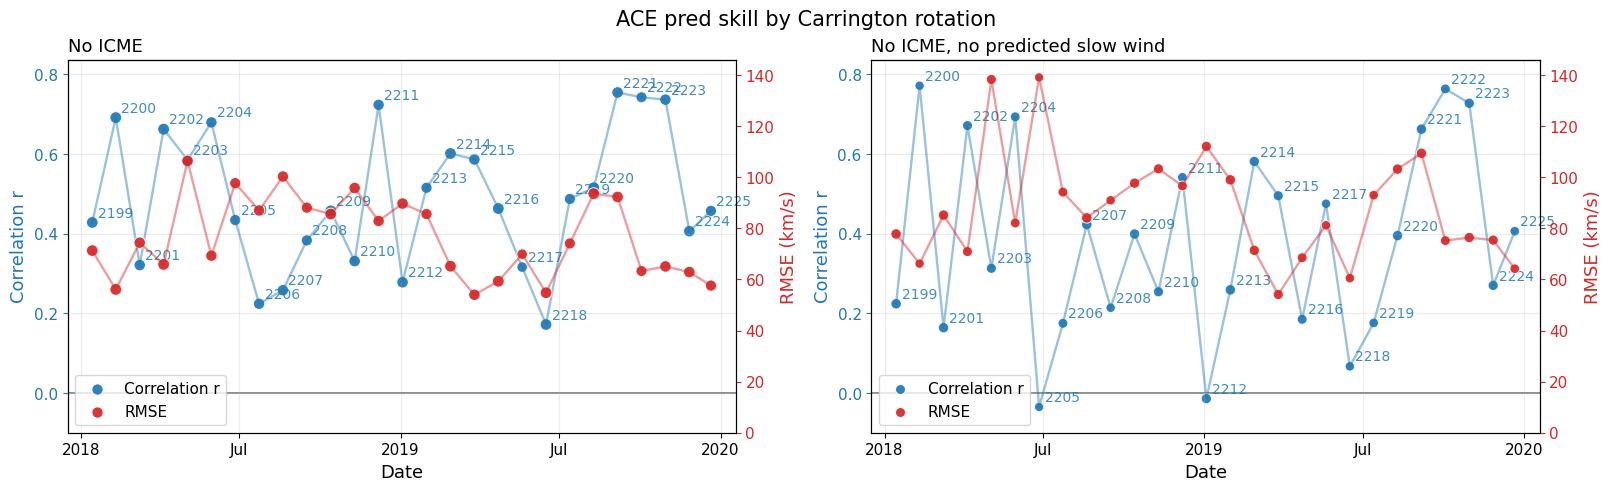

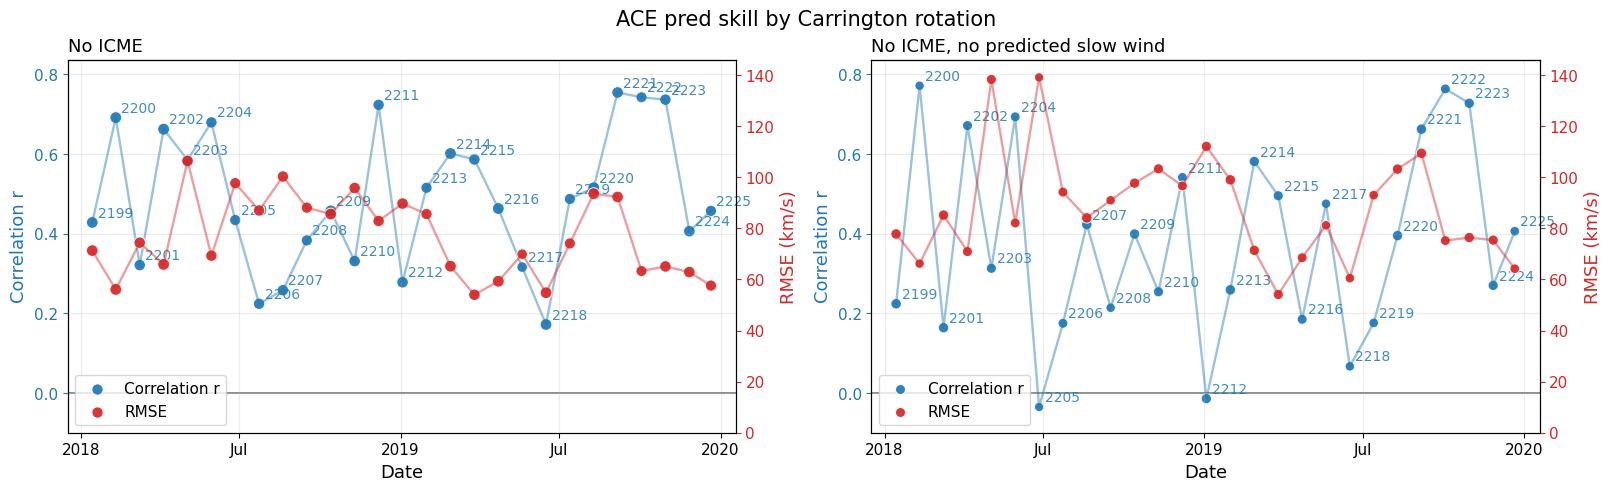

In [88]:
ace_per_cr_fig = plot_corr_frame(
    per_cr_df,
    sat="ACE @ Earth",
    regimes=SAT_REGIMES["ACE @ Earth"],
    title="ACE pred skill by Carrington rotation",
    marker="o",
    outfile=OUT_DIR / "ACE Pred Skill Per-CR.png",
    x_column="cr_mid",
    xlabel="Date",
    stereo_age_axis=False,
    empty_top_axis=True,
)
ace_per_cr_fig


/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_2192/3239572622.py:32: UserWarning: Discarding nonzero nanoseconds in conversion.
  return mdates.date2num([value.to_pydatetime() for value in date_values])


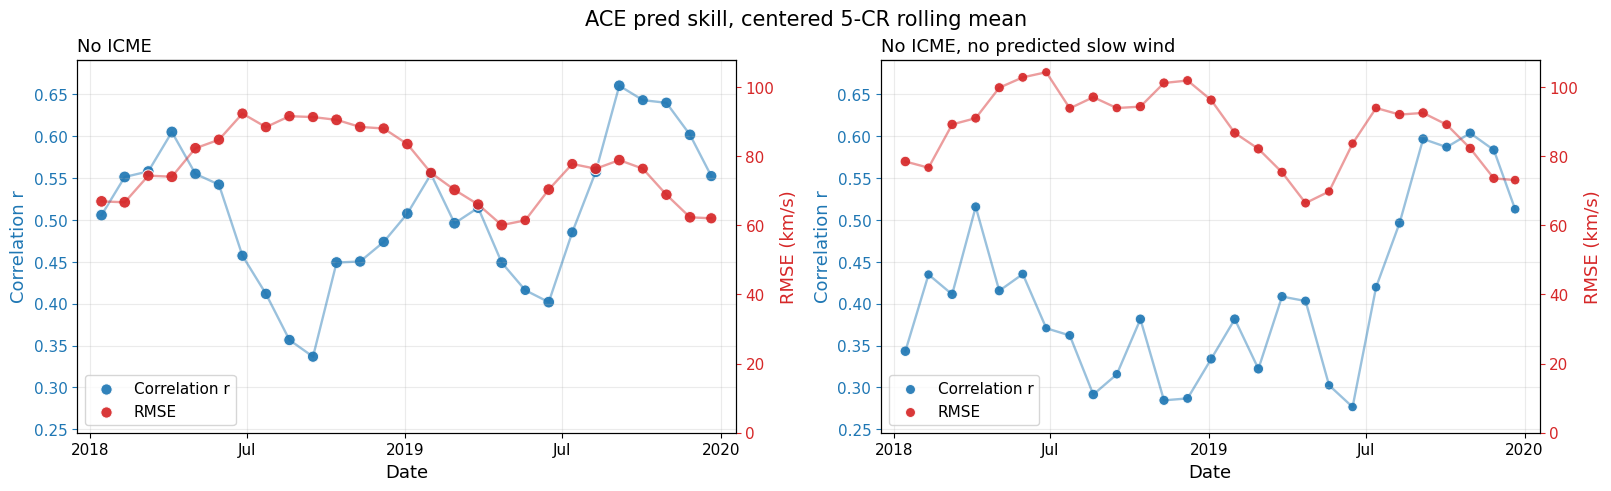

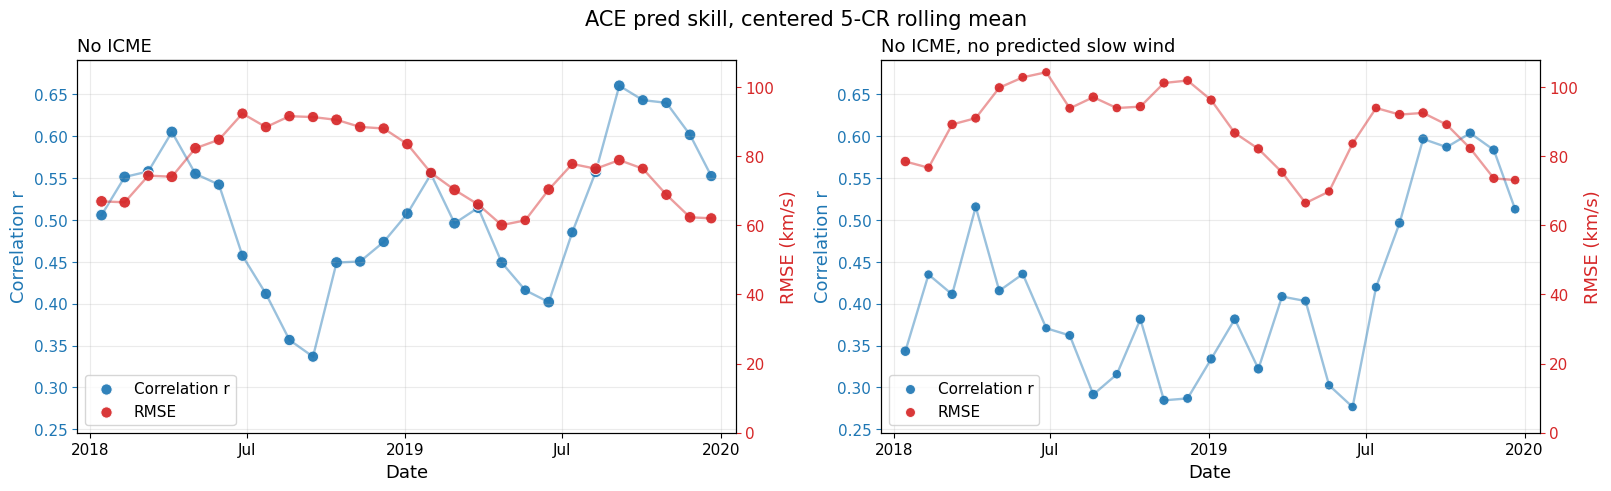

In [89]:
ace_rolling_fig = plot_corr_frame(
    rolling_df,
    sat="ACE @ Earth",
    regimes=SAT_REGIMES["ACE @ Earth"],
    title=f"ACE pred skill, centered {ROLLING_WINDOW}-CR rolling mean",
    marker="o",
    outfile=OUT_DIR / f"ACE Pred Skill Rolling-{ROLLING_WINDOW}.png",
    x_column="cr_mid",
    xlabel="Date",
    stereo_age_axis=False,
    empty_top_axis=True,
    annotate=False,
)
ace_rolling_fig


## STEREO-A plots

STEREO-A keeps the azimuth bottom axis and CH observation age top axis.


/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_2192/3239572622.py:32: UserWarning: Discarding nonzero nanoseconds in conversion.
  return mdates.date2num([value.to_pydatetime() for value in date_values])
/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_2192/3239572622.py:32: UserWarning: Discarding nonzero nanoseconds in conversion.
  return mdates.date2num([value.to_pydatetime() for value in date_values])
/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_2192/3239572622.py:32: UserWarning: Discarding nonzero nanoseconds in conversion.
  return mdates.date2num([value.to_pydatetime() for value in date_values])


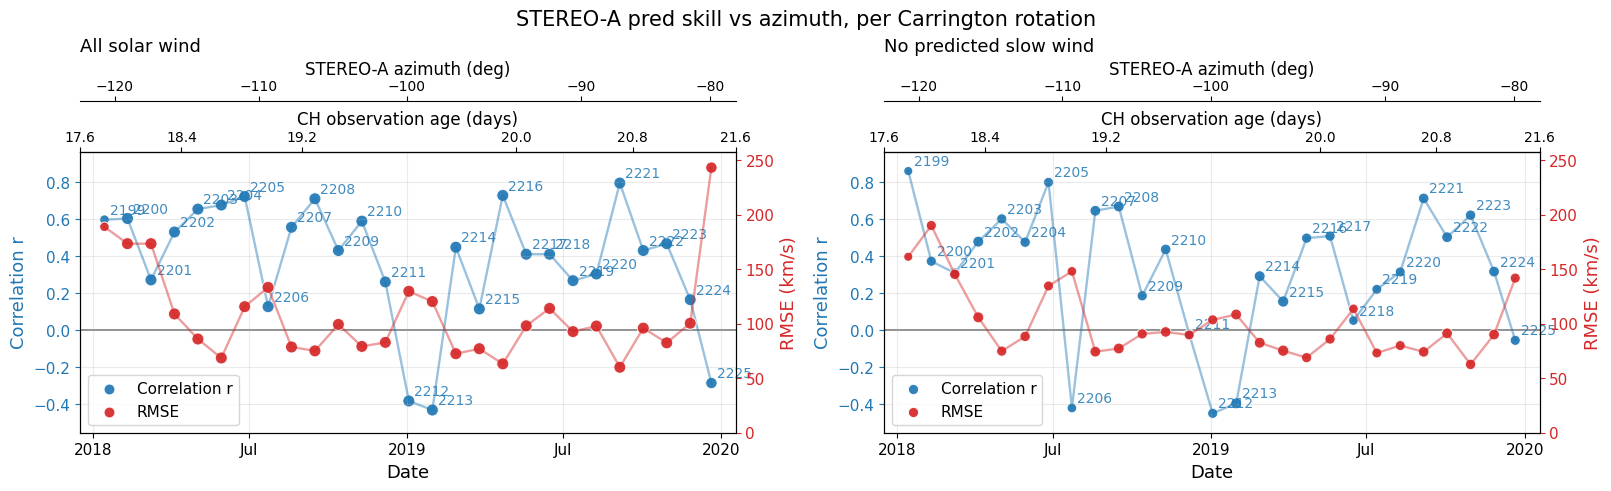

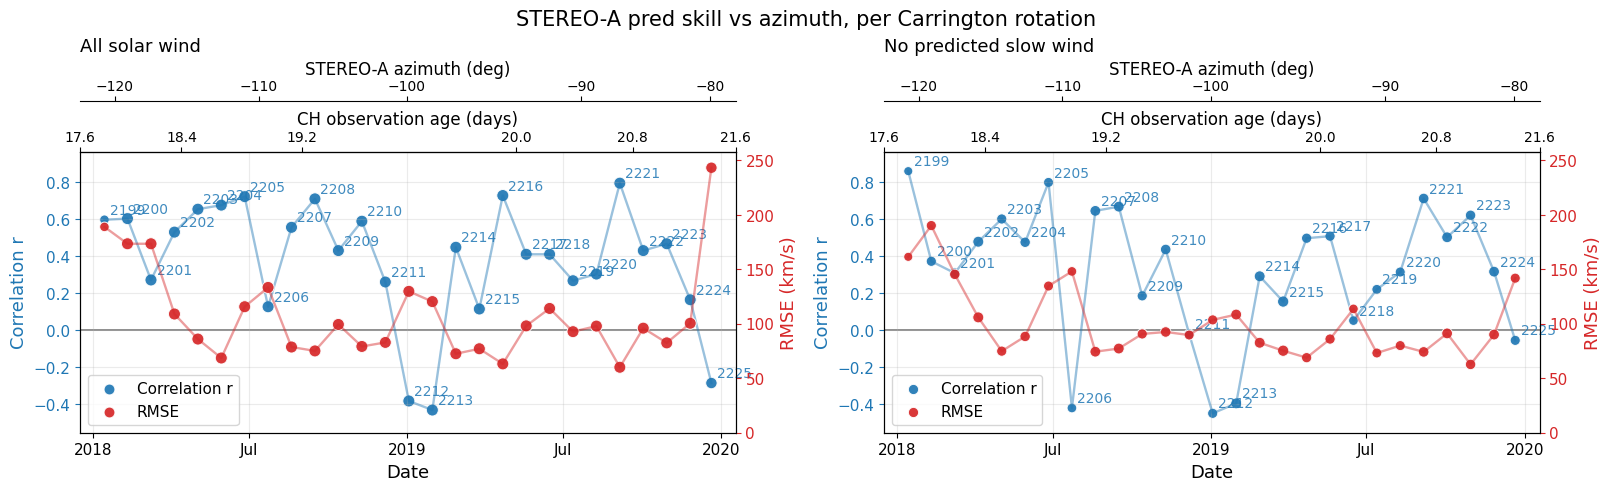

In [90]:
stereo_per_cr_fig = plot_corr_frame(
    per_cr_df,
    sat="STEREO-A",
    regimes=SAT_REGIMES["STEREO-A"],
    title="STEREO-A pred skill vs azimuth, per Carrington rotation",
    marker="o",
    outfile=OUT_DIR / "STEREO Pred Skill vs Azimuth Age Per-CR.png",
    x_column="cr_mid",
    xlabel="Date",
    stereo_age_axis=True,
)
stereo_per_cr_fig


/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_2192/3239572622.py:32: UserWarning: Discarding nonzero nanoseconds in conversion.
  return mdates.date2num([value.to_pydatetime() for value in date_values])
/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_2192/3239572622.py:32: UserWarning: Discarding nonzero nanoseconds in conversion.
  return mdates.date2num([value.to_pydatetime() for value in date_values])
/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_2192/3239572622.py:32: UserWarning: Discarding nonzero nanoseconds in conversion.
  return mdates.date2num([value.to_pydatetime() for value in date_values])


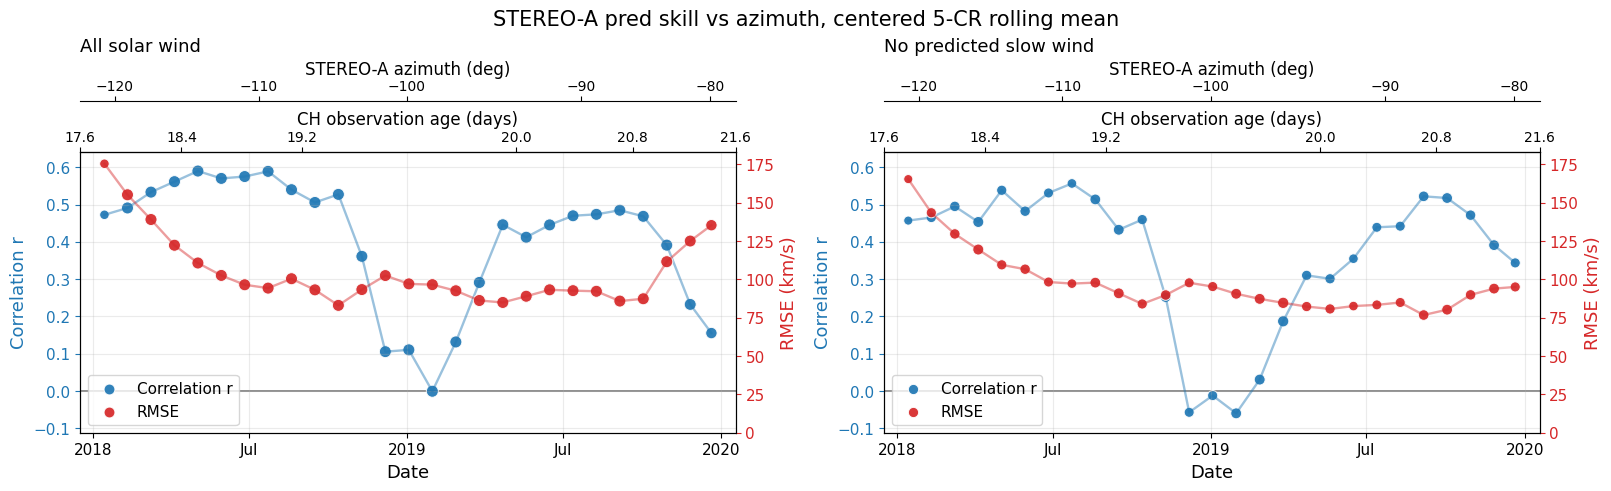

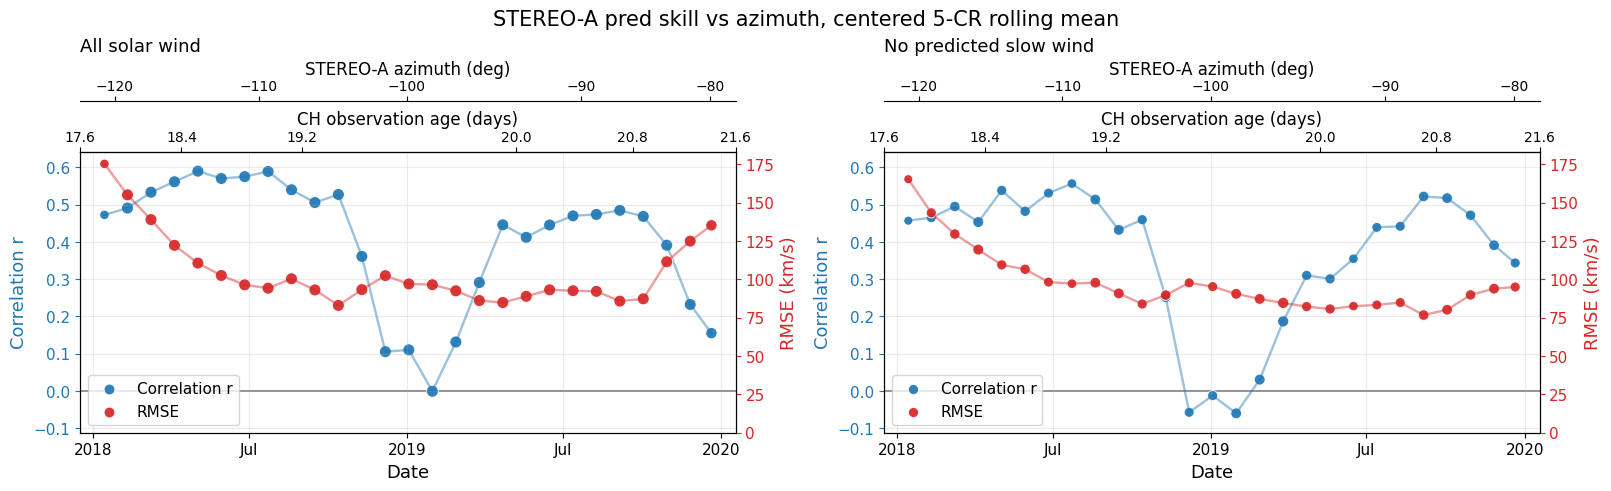

In [91]:
stereo_rolling_fig = plot_corr_frame(
    rolling_df,
    sat="STEREO-A",
    regimes=SAT_REGIMES["STEREO-A"],
    title=f"STEREO-A pred skill vs azimuth, centered {ROLLING_WINDOW}-CR rolling mean",
    marker="o",
    outfile=OUT_DIR / f"STEREO Pred Skill vs Azimuth Age Rolling-{ROLLING_WINDOW}.png",
    x_column="cr_mid",
    xlabel="Date",
    stereo_age_axis=True,
    annotate=False,
)
stereo_rolling_fig


## Saved outputs


In [92]:
saved_outputs = {
    "combined_per_cr_csv": OUT_DIR / "ACE Stereo Pred Corr Per-CR.csv",
    "combined_rolling_csv": OUT_DIR / f"ACE Stereo Pred Corr Rolling-{ROLLING_WINDOW}.csv",
    "ace_per_cr_png": OUT_DIR / "ACE Pred Skill Per-CR.png",
    "ace_rolling_png": OUT_DIR / f"ACE Pred Skill Rolling-{ROLLING_WINDOW}.png",
    "stereo_per_cr_png": OUT_DIR / "STEREO Pred Skill vs Azimuth Age Per-CR.png",
    "stereo_rolling_png": OUT_DIR / f"STEREO Pred Skill vs Azimuth Age Rolling-{ROLLING_WINDOW}.png",
}
saved_outputs


{'combined_per_cr_csv': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/from Miracle 2/SW/Plots/ACE Stereo Pred Corr Per-CR.csv'),
 'combined_rolling_csv': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/from Miracle 2/SW/Plots/ACE Stereo Pred Corr Rolling-5.csv'),
 'ace_per_cr_png': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/from Miracle 2/SW/Plots/ACE Pred Skill Per-CR.png'),
 'ace_rolling_png': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/from Miracle 2/SW/Plots/ACE Pred Skill Rolling-5.png'),
 'stereo_per_cr_png': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/from Miracle 2/SW/Plots/STEREO Pred Skill vs Azimuth Age Per-CR.png'),
 'stereo_rolling_png': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/from Miracle 2/SW/Plots/STEREO Pred Skill vs Azimuth Age Rolling-5.png')}